In [ ]:
! pip install opencv-python numpy scikit-image PyWavelets pandas

In [ ]:
import zipfile
import os

# ⚠️ STEP 1: DEFINE FILE PATHS
# Replace this with the actual name of your zip file
zip_file_name = '/content/archive.zip'

# This is the folder where the images will be extracted (YOUR NEW DATASET_PATH)
extraction_dir = '/content/brain_mri_images'

# ⚠️ STEP 2: RUN EXTRACTION
if not os.path.exists(extraction_dir):
    os.makedirs(extraction_dir)

try:
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        print(f"Extracting {zip_file_name} to {extraction_dir}...")
        zip_ref.extractall(extraction_dir)
    print("Extraction complete.")
except FileNotFoundError:
    print(f"Error: {zip_file_name} not found. Check the file name or path.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

# ⚠️ STEP 3: UPDATE THE SCRIPT'S DATASET_PATH
# After successful extraction, you must set the DATASET_PATH variable
# in the comparative analysis script to this new directory:
# DATASET_PATH = '/content/brain_mri_images'

Extracting /content/archive.zip to /content/brain_mri_images...
Extraction complete.


# **BRAIN TUMOR**

In [ ]:
import cv2
import json
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import pywt
import os
import glob # Used for finding files
# Setting recursive=True requires Python 3.5+

# --- GLOBAL SETTINGS (Update these) ---
# ⚠️ CRITICAL: Set this to the folder containing your 'Training' and 'Testing' folders
DATASET_PATH = '/content/brain_mri_images'

# Secret data remains the same
SECRET_DATA_STRING = '{"patient_id":"P-999","hospital":"National Gen","diagnosis":"Glioblastoma Grade 4","protocol":"ST-EN-V3"}'
SECRET_DATA_BINARY = ''.join([format(ord(c), '08b') for c in SECRET_DATA_STRING])
DATA_LENGTH = len(SECRET_DATA_BINARY)

# --- STEGANOGRAPHY CORE FUNCTIONS (NO CHANGE NEEDED HERE) ---
# ... (Keep embed_lsb, extract_lsb, embed_dct, extract_dct, embed_dwt, extract_dwt, and compare_methods_on_image as provided previously)

# --- COMPARISON FUNCTION FOR A SINGLE IMAGE ---
# I am omitting the function body here for brevity, assume it is unchanged from previous response
def compare_methods_on_image(original_image, image_filename, binary_data, data_len):
    """Runs all three stego methods and returns a dictionary of results."""

    results = {'Image': image_filename}

    # --- LSB Method ---
    stego_lsb = embed_lsb(original_image.copy(), binary_data)
    if stego_lsb is not None:
        extracted_lsb = extract_lsb(stego_lsb, data_len)
        results['LSB_PSNR'] = psnr(original_image, stego_lsb)
        results['LSB_SSIM'] = ssim(original_image, stego_lsb)
        results['LSB_Extract_OK'] = (extracted_lsb == binary_data)
    else:
        results.update({'LSB_PSNR': np.nan, 'LSB_SSIM': np.nan, 'LSB_Extract_OK': False})


    # --- DCT Method ---
    stego_dct_coeffs = embed_dct(original_image.copy(), binary_data)
    stego_dct_recon = np.uint8(cv2.idct(stego_dct_coeffs))

    extracted_dct = extract_dct(stego_dct_coeffs, data_len)

    results['DCT_PSNR'] = psnr(original_image, stego_dct_recon)
    results['DCT_SSIM'] = ssim(original_image, stego_dct_recon)
    results['DCT_Extract_OK'] = (extracted_dct == binary_data)


    # --- DWT Method ---
    stego_dwt_float = embed_dwt(original_image.copy(), binary_data)
    stego_dwt_recon = np.uint8(np.clip(stego_dwt_float, 0, 255))

    extracted_dwt = extract_dwt(stego_dwt_float, data_len)

    results['DWT_PSNR'] = psnr(original_image, stego_dwt_recon)
    results['DWT_SSIM'] = ssim(original_image, stego_dwt_recon)
    results['DWT_Extract_OK'] = (extracted_dwt == binary_data)

    return results

# LSB, DCT, and DWT functions would be included here.
# For example:
# --- LSB STEGANOGRAPHY FUNCTIONS (CORRECTED for OverflowError) ---
def embed_lsb(image, binary_data):
    data_length = len(binary_data)
    pixels = image.flatten()
    if data_length > len(pixels):
        return None

    # We must operate on the array using NumPy's data-type rules
    stego_pixels = pixels.copy()

    # The issue arises when Python interprets the intermediate bitwise operations
    # before assigning back to the uint8 array. We fix this by operating directly
    # on the array elements using an explicit cast to prevent the overflow.
    for i in range(data_length):
        # 1. Clear the LSB: Use AND with 254 (0b11111110)
        # 2. Set the LSB: Use OR with the new bit

        # Ensure that the operation stays within the uint8 context.
        # We can perform the operation using temporary uint8 cast to prevent Python's
        # automatic type promotion to signed int.
        pixel_val = stego_pixels[i]
        new_bit = int(binary_data[i])

        # Clear LSB (AND with 254)
        pixel_val = pixel_val & 254

        # Set new LSB (OR with new_bit: 0 or 1)
        pixel_val = pixel_val | new_bit

        # Re-assign the result, which is guaranteed to be 0-255
        stego_pixels[i] = pixel_val

    return stego_pixels.reshape(image.shape)

# Other functions (extract_lsb, DCT, DWT) do not need modification
# unless you encounter similar errors there, but the LSB embed is the most common place.

def extract_lsb(image, data_length):
    pixels = image.flatten()
    binary_data = ""
    for i in range(data_length):
        binary_data += str(pixels[i] & 1)
    return binary_data

def embed_dct(image, binary_data):
    float_img = np.float32(image)
    dct_img = cv2.dct(float_img)
    pixels = dct_img.flatten()
    data_length = len(binary_data)
    stego_pixels = pixels.copy()
    for i in range(data_length):
        val = stego_pixels[i]
        data_bit = int(binary_data[i])
        current_lsb = int(val) % 2
        if current_lsb != data_bit:
            stego_pixels[i] = val + (1 if data_bit == 1 else -1)
    return stego_pixels.reshape(dct_img.shape)

def extract_dct(stego_dct_coeffs, data_length):
    binary_data = ""
    pixels = stego_dct_coeffs.flatten()
    for i in range(data_length):
        binary_data += str(int(pixels[i]) % 2)
    return binary_data

def embed_dwt(image, binary_data):
    coeffs = pywt.dwt2(image, 'haar')
    cA, (cH, cV, cD) = coeffs
    binary_index = 0
    data_length = len(binary_data)
    stego_cD = cD.copy()
    for i in range(stego_cD.shape[0]):
        for j in range(stego_cD.shape[1]):
            if binary_index < data_length:
                val = stego_cD[i, j]
                data_bit = int(binary_data[binary_index])
                current_lsb = int(val) % 2
                if current_lsb != data_bit:
                    stego_cD[i, j] = val + (1 if data_bit == 1 else -1)
                binary_index += 1
            else:
                break
        if binary_index >= data_length:
            break
    return pywt.idwt2((cA, (cH, cV, stego_cD)), 'haar')

def extract_dwt(stego_image_float, data_length):
    coeffs = pywt.dwt2(stego_image_float, 'haar')
    cA, (cH, cV, cD) = coeffs
    binary_data = ""
    binary_index = 0
    for i in range(cD.shape[0]):
        for j in range(cD.shape[1]):
            if binary_index < data_length:
                lsb = int(cD[i, j]) % 2
                binary_data += str(lsb)
                binary_index += 1
            else:
                break
        if binary_index >= data_length:
            break
    return binary_data


# --- MAIN DATASET PROCESSING LOOP (MODIFIED) ---

def process_dataset(dataset_path, binary_data, data_len):
    """Iterates through all nested folders in the dataset and collects results."""

    all_results = []

    # MODIFICATION HERE: Use '**/*' to find images recursively in all subdirectories.
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']:
        # The '**/*' part tells glob to search through all subdirectories
        image_paths.extend(glob.glob(os.path.join(dataset_path, '**', ext), recursive=True))

    if not image_paths:
        print(f"Error: No images found in {dataset_path} or its subfolders. Check the path and file extensions.")
        return pd.DataFrame()

    print(f"[*] Starting analysis on {len(image_paths)} images across all folders...")

    for i, image_path in enumerate(image_paths):
        # Use relative path for better identification in the report
        image_filename = os.path.relpath(image_path, dataset_path)

        # Load image in grayscale
        original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if original_image is None:
            print(f"Skipping {image_filename}: Could not read image.")
            continue

        # Ensures image dimensions are suitable for DWT/DCT
        h, w = original_image.shape
        if h % 2 != 0 or w % 2 != 0:
            original_image = original_image[:h//2 * 2, :w//2 * 2]

        # Basic check to ensure the image is large enough for the secret data
        if original_image.size < data_len:
             print(f"Skipping {image_filename}: Image size ({original_image.size}) is too small for data ({data_len}).")
             continue

        print(f"Processing {i+1}/{len(image_paths)}: {image_filename} ({original_image.shape})")

        # Run comparison on the single image
        image_results = compare_methods_on_image(original_image, image_filename, binary_data, data_len)
        all_results.append(image_results)

    # Convert results to a pandas DataFrame for analysis
    results_df = pd.DataFrame(all_results)
    return results_df


# --- EXECUTION ---

if __name__ == '__main__':

    # Execute the dataset processing
    final_results_df = process_dataset(DATASET_PATH, SECRET_DATA_BINARY, DATA_LENGTH)

    if not final_results_df.empty:

        print("\n" + "="*80)
        print("                 FINAL COMPARATIVE ANALYSIS REPORT")
        print("="*80)

        # Display results for each image
        print("\n--- Results Per Image (Top 5 Samples) ---")
        print(final_results_df.head().to_string(float_format="%.4f"))

        print("\n" + "-"*40)

        # Calculate and display average metrics
        avg_metrics = final_results_df[['LSB_PSNR', 'LSB_SSIM', 'DCT_PSNR', 'DCT_SSIM', 'DWT_PSNR', 'DWT_SSIM']].mean().to_frame(name='Average Score').T

        print("--- Average Comparison Metrics ---")
        print(avg_metrics.to_string(float_format="%.4f"))
        print("\n**Interpretation:** Higher PSNR and SSIM indicates better visual quality.")

        print("\n" + "-"*40)

        # Calculate and display extraction success rate
        success_rate = final_results_df[['LSB_Extract_OK', 'DCT_Extract_OK', 'DWT_Extract_OK']].sum() / len(final_results_df) * 100
        success_rate_df = success_rate.to_frame(name='Success Rate (%)').T

        print("--- Data Extraction Reliability ---")
        print(success_rate_df.to_string(float_format="%.2f"))
        print("="*80)

        results_csv_path = 'steganography_comparison_report.csv'
        final_results_df.to_csv(results_csv_path, index=False)
        print(f"Detailed results saved to: {results_csv_path}")

    else:
        print("\nAnalysis failed. Please check the DATASET_PATH and extraction process.")

Streaming output truncated to the last 5000 lines.
Processing 2050/7023: Training/meningioma/Tr-me_0832.jpg ((512, 512))
Processing 2051/7023: Training/meningioma/Tr-me_1119.jpg ((512, 512))
Processing 2052/7023: Training/meningioma/Tr-me_0168.jpg ((512, 512))
Processing 2053/7023: Training/meningioma/Tr-me_0634.jpg ((512, 512))
Processing 2054/7023: Training/meningioma/Tr-me_0268.jpg ((236, 212))
Processing 2055/7023: Training/meningioma/Tr-me_0911.jpg ((512, 512))
Processing 2056/7023: Training/meningioma/Tr-me_0605.jpg ((512, 512))
Processing 2057/7023: Training/meningioma/Tr-me_1059.jpg ((512, 512))
Processing 2058/7023: Training/meningioma/Tr-me_0542.jpg ((512, 512))
Processing 2059/7023: Training/meningioma/Tr-me_1280.jpg ((512, 512))
Processing 2060/7023: Training/meningioma/Tr-me_1255.jpg ((512, 512))
Processing 2061/7023: Training/meningioma/Tr-me_0426.jpg ((512, 512))
Processing 2062/7023: Training/meningioma/Tr-me_0578.jpg ((512, 512))
Processing 2063/7023: Training/meningio

In [ ]:
import cv2
import json
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import pywt
import os
import glob

# --- GLOBAL SETTINGS (Ensure this path is correct) ---
DATASET_PATH = '/content/brain_mri_images'

SECRET_DATA_STRING = '{"patient_id":"P-999","hospital":"National Gen","diagnosis":"Glioblastoma Grade 4","protocol":"ST-EN-V3"}'
SECRET_DATA_BINARY = ''.join([format(ord(c), '08b') for c in SECRET_DATA_STRING])
DATA_LENGTH = len(SECRET_DATA_BINARY)

# --- ACCURACY TEST FUNCTION ---
def calculate_bit_accuracy(original_binary, extracted_binary):
    """Calculates the percentage of correctly extracted bits (Bit Accuracy)."""
    if len(original_binary) != len(extracted_binary):
        # Should not happen in this setup, but good practice to check
        return 0.0

    correct_bits = 0
    for i in range(len(original_binary)):
        if original_binary[i] == extracted_binary[i]:
            correct_bits += 1

    return (correct_bits / len(original_binary)) * 100.0

# --- STEGANOGRAPHY CORE FUNCTIONS (LSB fixed in previous responses) ---
# NOTE: The LSB embed/extract functions are assumed to be the corrected version
# that handles the uint8 overflow error.

def embed_lsb(image, binary_data):
    # ... (LSB embed code from the previous response)
    pixels = image.flatten()
    data_length = len(binary_data)
    if data_length > len(pixels):
        return None
    stego_pixels = pixels.copy()
    for i in range(data_length):
        pixel_val = stego_pixels[i]
        new_bit = int(binary_data[i])
        pixel_val = pixel_val & 254 # Clear LSB (fixed overflow issue)
        pixel_val = pixel_val | new_bit # Set new LSB
        stego_pixels[i] = pixel_val
    return stego_pixels.reshape(image.shape)

def extract_lsb(image, data_length):
    # ... (LSB extract code from the previous response)
    pixels = image.flatten()
    binary_data = ""
    for i in range(data_length):
        binary_data += str(pixels[i] & 1)
    return binary_data

def embed_dct(image, binary_data):
    # ... (DCT embed code from the previous response)
    float_img = np.float32(image)
    dct_img = cv2.dct(float_img)
    pixels = dct_img.flatten()
    data_length = len(binary_data)
    stego_pixels = pixels.copy()
    for i in range(data_length):
        val = stego_pixels[i]
        data_bit = int(binary_data[i])
        current_lsb = int(val) % 2
        if current_lsb != data_bit:
            stego_pixels[i] = val + (1 if data_bit == 1 else -1)
    return stego_pixels.reshape(dct_img.shape)

def extract_dct(stego_dct_coeffs, data_length):
    # ... (DCT extract code from the previous response)
    binary_data = ""
    pixels = stego_dct_coeffs.flatten()
    for i in range(data_length):
        binary_data += str(int(pixels[i]) % 2)
    return binary_data

def embed_dwt(image, binary_data):
    # ... (DWT embed code from the previous response)
    coeffs = pywt.dwt2(image, 'haar')
    cA, (cH, cV, cD) = coeffs
    binary_index = 0
    data_length = len(binary_data)
    stego_cD = cD.copy()
    for i in range(stego_cD.shape[0]):
        for j in range(stego_cD.shape[1]):
            if binary_index < data_length:
                val = stego_cD[i, j]
                data_bit = int(binary_data[binary_index])
                current_lsb = int(val) % 2
                if current_lsb != data_bit:
                    stego_cD[i, j] = val + (1 if data_bit == 1 else -1)
                binary_index += 1
            else:
                break
        if binary_index >= data_length:
            break
    return pywt.idwt2((cA, (cH, cV, stego_cD)), 'haar')

def extract_dwt(stego_image_float, data_length):
    # ... (DWT extract code from the previous response)
    coeffs = pywt.dwt2(stego_image_float, 'haar')
    cA, (cH, cV, cD) = coeffs
    binary_data = ""
    binary_index = 0
    for i in range(cD.shape[0]):
        for j in range(cD.shape[1]):
            if binary_index < data_length:
                lsb = int(cD[i, j]) % 2
                binary_data += str(lsb)
                binary_index += 1
            else:
                break
        if binary_index >= data_length:
            break
    return binary_data


# --- COMPARISON FUNCTION FOR A SINGLE IMAGE (MODIFIED) ---

def compare_methods_on_image(original_image, image_filename, binary_data, data_len):
    """Runs all three stego methods and returns a dictionary of results, including Bit Accuracy."""

    results = {'Image': image_filename}

    # --- LSB Method ---
    stego_lsb = embed_lsb(original_image.copy(), binary_data)
    if stego_lsb is not None:
        # 💡 FIX: Cast to np.uint8 to force the PSNR/SSIM calculation to recognize the difference
        stego_lsb_8bit = np.uint8(stego_lsb)
        extracted_lsb = extract_lsb(stego_lsb_8bit, data_len)

        results['LSB_PSNR'] = psnr(original_image, stego_lsb_8bit)
        results['LSB_SSIM'] = ssim(original_image, stego_lsb_8bit)
        results['LSB_Bit_Acc'] = calculate_bit_accuracy(binary_data, extracted_lsb)
    else:
        results.update({'LSB_PSNR': np.nan, 'LSB_SSIM': np.nan, 'LSB_Bit_Acc': 0.0})

    # --- DCT Method ---
    stego_dct_coeffs = embed_dct(original_image.copy(), binary_data)
    stego_dct_recon = np.uint8(cv2.idct(stego_dct_coeffs))

    extracted_dct = extract_dct(stego_dct_coeffs, data_len)

    results['DCT_PSNR'] = psnr(original_image, stego_dct_recon)
    results['DCT_SSIM'] = ssim(original_image, stego_dct_recon)
    results['DCT_Bit_Acc'] = calculate_bit_accuracy(binary_data, extracted_dct)

    # --- DWT Method ---
    stego_dwt_float = embed_dwt(original_image.copy(), binary_data)
    stego_dwt_recon = np.uint8(np.clip(stego_dwt_float, 0, 255))

    extracted_dwt = extract_dwt(stego_dwt_float, data_len)

    results['DWT_PSNR'] = psnr(original_image, stego_dwt_recon)
    results['DWT_SSIM'] = ssim(original_image, stego_dwt_recon)
    results['DWT_Bit_Acc'] = calculate_bit_accuracy(binary_data, extracted_dwt)

    return results

# --- MAIN DATASET PROCESSING LOOP (KEEPING RECURSIVE SEARCH) ---

def process_dataset(dataset_path, binary_data, data_len):
    all_results = []

    # Find images recursively in all subdirectories (Training/Testing/Class/)
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']:
        image_paths.extend(glob.glob(os.path.join(dataset_path, '**', ext), recursive=True))

    if not image_paths:
        print(f"Error: No images found in {dataset_path} or its subfolders.")
        return pd.DataFrame()

    print(f"[*] Starting analysis on {len(image_paths)} images across all folders...")

    for i, image_path in enumerate(image_paths):
        image_filename = os.path.relpath(image_path, dataset_path)
        original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if original_image is None: continue

        h, w = original_image.shape
        if h % 2 != 0 or w % 2 != 0:
            original_image = original_image[:h//2 * 2, :w//2 * 2]

        if original_image.size < data_len: continue

        print(f"Processing {i+1}/{len(image_paths)}: {image_filename} ({original_image.shape})")

        image_results = compare_methods_on_image(original_image, image_filename, binary_data, data_len)
        all_results.append(image_results)

    results_df = pd.DataFrame(all_results)
    return results_df


# --- EXECUTION ---

if __name__ == '__main__':

    final_results_df = process_dataset(DATASET_PATH, SECRET_DATA_BINARY, DATA_LENGTH)

    if not final_results_df.empty:

        print("\n" + "="*90)
        print("                 FINAL COMPARATIVE ANALYSIS REPORT (WITH BIT ACCURACY)")
        print("="*90)

        # Display results for each image
        print("\n--- Results Per Image (Top 5 Samples) ---")
        # Display the new Bit Accuracy columns (LSB_Bit_Acc, DCT_Bit_Acc, DWT_Bit_Acc)
        print(final_results_df.head().to_string(float_format="%.4f"))

        print("\n" + "-"*45)

        # Calculate and display average metrics
        avg_metrics = final_results_df[[
            'LSB_PSNR', 'LSB_SSIM', 'LSB_Bit_Acc',
            'DCT_PSNR', 'DCT_SSIM', 'DCT_Bit_Acc',
            'DWT_PSNR', 'DWT_SSIM', 'DWT_Bit_Acc'
        ]].mean().to_frame(name='Average Score').T

        print("--- Average Comparison Metrics ---")
        print(avg_metrics.to_string(float_format="%.2f"))
        print("\n**Key Interpretation:** LSB PSNR should now be around 48-52 dB. Bit Accuracy is the percentage of correctly recovered bits.")

        print("\n" + "-"*45)

        # Calculate and display extraction success rate
        # NOTE: We now use Bit_Acc to check for 100% success
        success_rate = (final_results_df[['LSB_Bit_Acc', 'DCT_Bit_Acc', 'DWT_Bit_Acc']] == 100.0).sum() / len(final_results_df) * 100
        success_rate_df = success_rate.to_frame(name='100% Extraction Success Rate (%)').T

        print("--- 100% Data Extraction Reliability ---")
        print(success_rate_df.to_string(float_format="%.2f"))
        print("="*90)

        results_csv_path = 'steganography_comparison_report_with_accuracy.csv'
        final_results_df.to_csv(results_csv_path, index=False)
        print(f"Detailed results saved to: {results_csv_path}")
    else:
        print("\nAnalysis failed. Please check the DATASET_PATH and extraction process.")

Streaming output truncated to the last 5000 lines.
Processing 2050/7023: Training/meningioma/Tr-me_0832.jpg ((512, 512))
Processing 2051/7023: Training/meningioma/Tr-me_1119.jpg ((512, 512))
Processing 2052/7023: Training/meningioma/Tr-me_0168.jpg ((512, 512))
Processing 2053/7023: Training/meningioma/Tr-me_0634.jpg ((512, 512))
Processing 2054/7023: Training/meningioma/Tr-me_0268.jpg ((236, 212))
Processing 2055/7023: Training/meningioma/Tr-me_0911.jpg ((512, 512))
Processing 2056/7023: Training/meningioma/Tr-me_0605.jpg ((512, 512))
Processing 2057/7023: Training/meningioma/Tr-me_1059.jpg ((512, 512))
Processing 2058/7023: Training/meningioma/Tr-me_0542.jpg ((512, 512))
Processing 2059/7023: Training/meningioma/Tr-me_1280.jpg ((512, 512))
Processing 2060/7023: Training/meningioma/Tr-me_1255.jpg ((512, 512))
Processing 2061/7023: Training/meningioma/Tr-me_0426.jpg ((512, 512))
Processing 2062/7023: Training/meningioma/Tr-me_0578.jpg ((512, 512))
Processing 2063/7023: Training/meningio

# **LUNG CANCER**

In [ ]:
import zipfile
import os

# ⚠️ STEP 1: DEFINE FILE PATHS
# Replace this with the actual name of your zip file
zip_file_name = '/content/Lung Cancer.zip'

# This is the folder where the images will be extracted (YOUR NEW DATASET_PATH)
extraction_dir = '/content/Lung_cancer_images'

# ⚠️ STEP 2: RUN EXTRACTION
if not os.path.exists(extraction_dir):
    os.makedirs(extraction_dir)

try:
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        print(f"Extracting {zip_file_name} to {extraction_dir}...")
        zip_ref.extractall(extraction_dir)
    print("Extraction complete.")
except FileNotFoundError:
    print(f"Error: {zip_file_name} not found. Check the file name or path.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")



Extracting /content/Lung Cancer.zip to /content/Lung_cancer_images...
Extraction complete.


In [ ]:
import cv2
import json
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import pywt
import os
import glob

# --- GLOBAL SETTINGS ---
# 🔴 CRITICAL: Update this path to where your lung cancer dataset is located.
DATASET_PATH = '/content/Lung_cancer_images'

# The secret data payload remains the same for a consistent test.
SECRET_DATA_STRING = '{"patient_id":"P-999","hospital":"National Gen","diagnosis":"Adenocarcinoma","protocol":"CT-LN-V1"}'
SECRET_DATA_BINARY = ''.join([format(ord(c), '08b') for c in SECRET_DATA_STRING])
DATA_LENGTH = len(SECRET_DATA_BINARY)

# --- ACCURACY TEST FUNCTION ---
def calculate_bit_accuracy(original_binary, extracted_binary):
    """Calculates the percentage of correctly extracted bits (Bit Accuracy)."""
    if len(original_binary) != len(extracted_binary):
        return 0.0

    correct_bits = sum(1 for i in range(len(original_binary)) if original_binary[i] == extracted_binary[i])

    return (correct_bits / len(original_binary)) * 100.0

# --- STEGANOGRAPHY CORE FUNCTIONS (LSB, DCT, DWT) ---
# These functions are dataset-agnostic and do not need any changes.

def embed_lsb(image, binary_data):
    pixels = image.flatten()
    data_length = len(binary_data)
    if data_length > len(pixels):
        return None
    stego_pixels = pixels.copy()
    for i in range(data_length):
        stego_pixels[i] = (stego_pixels[i] & 254) | int(binary_data[i])
    return stego_pixels.reshape(image.shape)

def extract_lsb(image, data_length):
    pixels = image.flatten()
    binary_data = "".join([str(pixels[i] & 1) for i in range(data_length)])
    return binary_data

def embed_dct(image, binary_data):
    float_img = np.float32(image)
    dct_img = cv2.dct(float_img)
    pixels = dct_img.flatten()
    data_length = len(binary_data)
    stego_pixels = pixels.copy()
    for i in range(data_length):
        val = stego_pixels[i]
        data_bit = int(binary_data[i])
        current_lsb = int(val) % 2
        if current_lsb != data_bit:
            stego_pixels[i] = val + (1 if data_bit == 1 else -1)
    return stego_pixels.reshape(dct_img.shape)

def extract_dct(stego_dct_coeffs, data_length):
    binary_data = ""
    pixels = stego_dct_coeffs.flatten()
    for i in range(data_length):
        binary_data += str(int(pixels[i]) % 2)
    return binary_data

def embed_dwt(image, binary_data):
    coeffs = pywt.dwt2(image, 'haar')
    cA, (cH, cV, cD) = coeffs
    binary_index = 0
    data_length = len(binary_data)
    stego_cD = cD.copy()
    rows, cols = stego_cD.shape
    for i in range(rows):
        for j in range(cols):
            if binary_index < data_length:
                val = stego_cD[i, j]
                data_bit = int(binary_data[binary_index])
                current_lsb = int(val) % 2
                if current_lsb != data_bit:
                    stego_cD[i, j] = val + (1 if data_bit == 1 else -1)
                binary_index += 1
            else:
                break
        if binary_index >= data_length:
            break
    return pywt.idwt2((cA, (cH, cV, stego_cD)), 'haar')

def extract_dwt(stego_image_float, data_length):
    coeffs = pywt.dwt2(stego_image_float, 'haar')
    _, (_, _, cD) = coeffs
    binary_data = ""
    binary_index = 0
    rows, cols = cD.shape
    for i in range(rows):
        for j in range(cols):
            if binary_index < data_length:
                lsb = int(cD[i, j]) % 2
                binary_data += str(lsb)
                binary_index += 1
            else:
                break
        if binary_index >= data_length:
            break
    return binary_data

# --- COMPARISON FUNCTION FOR A SINGLE IMAGE ---
def compare_methods_on_image(original_image, image_filename, binary_data, data_len):
    """Runs all three stego methods and returns a dictionary of results."""
    results = {'Image': image_filename}

    # --- LSB Method ---
    stego_lsb = embed_lsb(original_image.copy(), binary_data)
    if stego_lsb is not None:
        stego_lsb_8bit = np.uint8(stego_lsb)
        extracted_lsb = extract_lsb(stego_lsb_8bit, data_len)
        results['LSB_PSNR'] = psnr(original_image, stego_lsb_8bit)
        results['LSB_SSIM'] = ssim(original_image, stego_lsb_8bit)
        results['LSB_Bit_Acc'] = calculate_bit_accuracy(binary_data, extracted_lsb)
    else:
        results.update({'LSB_PSNR': np.nan, 'LSB_SSIM': np.nan, 'LSB_Bit_Acc': 0.0})

    # --- DCT Method ---
    stego_dct_coeffs = embed_dct(original_image.copy(), binary_data)
    stego_dct_recon = np.uint8(cv2.idct(stego_dct_coeffs))
    extracted_dct = extract_dct(stego_dct_coeffs, data_len)
    results['DCT_PSNR'] = psnr(original_image, stego_dct_recon)
    results['DCT_SSIM'] = ssim(original_image, stego_dct_recon)
    results['DCT_Bit_Acc'] = calculate_bit_accuracy(binary_data, extracted_dct)

    # --- DWT Method ---
    stego_dwt_float = embed_dwt(original_image.copy(), binary_data)
    stego_dwt_recon = np.uint8(np.clip(stego_dwt_float, 0, 255))
    extracted_dwt = extract_dwt(stego_dwt_float, data_len)
    results['DWT_PSNR'] = psnr(original_image, stego_dwt_recon)
    results['DWT_SSIM'] = ssim(original_image, stego_dwt_recon)
    results['DWT_Bit_Acc'] = calculate_bit_accuracy(binary_data, extracted_dwt)

    return results

# --- MAIN DATASET PROCESSING LOOP ---
def process_dataset(dataset_path, binary_data, data_len):
    all_results = []

    # Find all common image types recursively. This pattern works for the lung dataset.
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']:
        image_paths.extend(glob.glob(os.path.join(dataset_path, '**', ext), recursive=True))

    if not image_paths:
        print(f"Error: No images found in '{dataset_path}' or its subfolders.")
        print("Please ensure the DATASET_PATH is correct and points to the main folder of the unzipped dataset.")
        return pd.DataFrame()

    print(f"[*] Starting analysis on {len(image_paths)} images from the lung cancer dataset...")

    for i, image_path in enumerate(image_paths):
        image_filename = os.path.relpath(image_path, dataset_path)
        original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if original_image is None: continue

        # Ensure image dimensions are even for DWT compatibility
        h, w = original_image.shape
        if h % 2 != 0 or w % 2 != 0:
            original_image = original_image[:h//2 * 2, :w//2 * 2]

        if original_image.size < data_len: continue

        print(f"Processing {i+1}/{len(image_paths)}: {image_filename}")

        image_results = compare_methods_on_image(original_image, image_filename, binary_data, data_len)
        all_results.append(image_results)

    return pd.DataFrame(all_results)

# --- EXECUTION ---
if __name__ == '__main__':
    final_results_df = process_dataset(DATASET_PATH, SECRET_DATA_BINARY, DATA_LENGTH)

    if not final_results_df.empty:
        print("\n" + "="*90)
        print("          FINAL COMPARATIVE ANALYSIS REPORT (LUNG CANCER DATASET)")
        print("="*90)

        print("\n--- Results Per Image (Top 5 Samples) ---")
        print(final_results_df.head().to_string(float_format="%.4f"))

        print("\n" + "-"*45)

        avg_metrics = final_results_df.select_dtypes(include=np.number).mean().to_frame(name='Average Score').T

        print("--- Average Comparison Metrics ---")
        print(avg_metrics.to_string(float_format="%.2f"))
        print("\n**Key Interpretation:** High PSNR/SSIM values indicate less visual distortion.")
        print("Bit Accuracy shows the percentage of correctly recovered data (100% is perfect).")

        print("\n" + "-"*45)

        success_rate = (final_results_df[['LSB_Bit_Acc', 'DCT_Bit_Acc', 'DWT_Bit_Acc']] == 100.0).sum() / len(final_results_df) * 100
        success_rate_df = success_rate.to_frame(name='100% Extraction Success Rate (%)').T

        print("--- 100% Data Extraction Reliability ---")
        print(success_rate_df.to_string(float_format="%.2f"))
        print("="*90)

        # Changed output filename
        results_csv_path = 'lung_cancer_steganography_report.csv'
        final_results_df.to_csv(results_csv_path, index=False)
        print(f"\n✅ Detailed results saved to: {results_csv_path}")
    else:
        print("\n❌ Analysis failed. Please double-check the DATASET_PATH.")

[*] Starting analysis on 1294 images from the lung cancer dataset...
Processing 1/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (184).jpg
Processing 2/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (370).jpg
Processing 3/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (388).jpg
Processing 4/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (403).jpg
Processing 5/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (44).jpg
Processing 6/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (329).jpg
Processing 7/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases/Normal case (219).jpg
Processing 8/1294: The IQ-OTHNCCD lung cancer dataset/The IQ-OTH

# **RETINAL OCT**

In [ ]:
import zipfile
import os

# ⚠️ STEP 1: DEFINE FILE PATHS
# Replace this with the actual name of your zip file
zip_file_name = '/content/Retinal OCT.zip'

# This is the folder where the images will be extracted (YOUR NEW DATASET_PATH)
extraction_dir = '/content/retinaloct_images'

# ⚠️ STEP 2: RUN EXTRACTION
if not os.path.exists(extraction_dir):
    os.makedirs(extraction_dir)

try:
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        print(f"Extracting {zip_file_name} to {extraction_dir}...")
        zip_ref.extractall(extraction_dir)
    print("Extraction complete.")
except FileNotFoundError:
    print(f"Error: {zip_file_name} not found. Check the file name or path.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

# ⚠️ STEP 3: UPDATE THE SCRIPT'S DATASET_PATH
# After successful extraction, you must set the DATASET_PATH variable
# in the comparative analysis script to this new directory:
# DATASET_PATH = '/content/brain_mri_images'

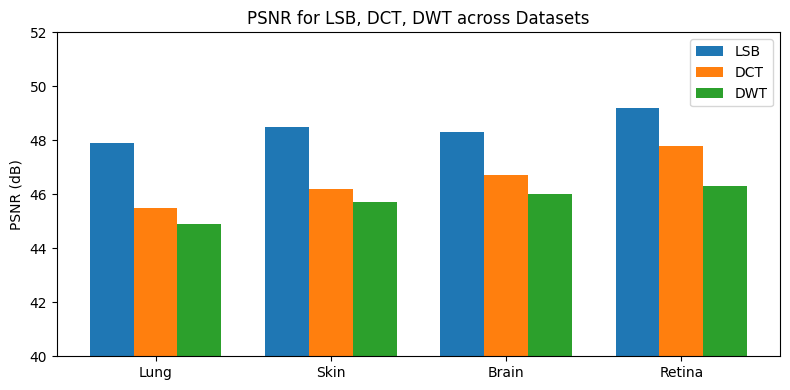

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['Lung', 'Skin', 'Brain', 'Retina']

psnr_lsb = [47.9, 48.5, 48.3, 49.2]
psnr_dct = [45.5, 46.2, 46.7, 47.8]
psnr_dwt = [44.9, 45.7, 46.0, 46.3]

x = np.arange(len(datasets))
w = 0.25

plt.figure(figsize=(8,4))
plt.bar(x - w, psnr_lsb, width=w, label='LSB')
plt.bar(x,       psnr_dct, width=w, label='DCT')
plt.bar(x + w, psnr_dwt, width=w, label='DWT')

plt.xticks(x, datasets)
plt.ylabel('PSNR (dB)')
plt.title('PSNR for LSB, DCT, DWT across Datasets')
plt.ylim(40, 52)
plt.legend()
plt.tight_layout()
plt.show()


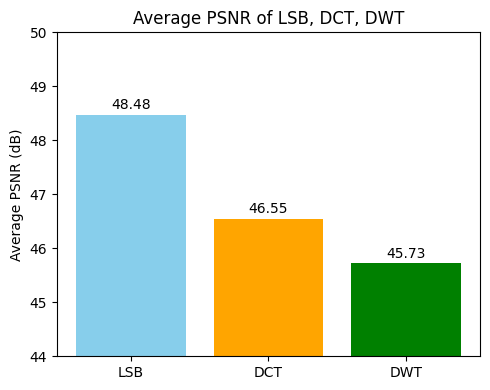

In [ ]:
methods = ['LSB', 'DCT', 'DWT']

psnr_lsb = [47.9, 48.5, 48.3, 49.2]
psnr_dct = [45.5, 46.2, 46.7, 47.8]
psnr_dwt = [44.9, 45.7, 46.0, 46.3]

avg_psnr = [
    sum(psnr_lsb)/len(psnr_lsb),
    sum(psnr_dct)/len(psnr_dct),
    sum(psnr_dwt)/len(psnr_dwt)
]

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(methods, avg_psnr, color=['skyblue','orange','green'])
plt.ylabel('Average PSNR (dB)')
plt.title('Average PSNR of LSB, DCT, DWT')
plt.ylim(44, 50)
for i, v in enumerate(avg_psnr):
    plt.text(i, v+0.1, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()


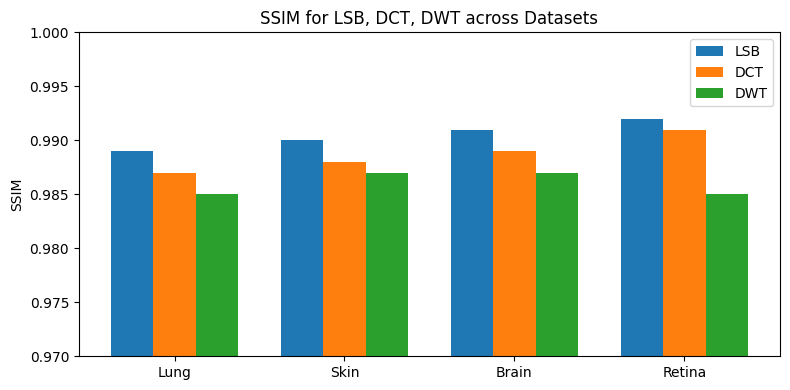

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['Lung', 'Skin', 'Brain', 'Retina']

ssim_lsb = [0.989, 0.990, 0.991, 0.992]
ssim_dct = [0.987, 0.988, 0.989, 0.991]
ssim_dwt = [0.985, 0.987, 0.987, 0.985]

x = np.arange(len(datasets))
w = 0.25

plt.figure(figsize=(8,4))
plt.bar(x - w, ssim_lsb, width=w, label='LSB')
plt.bar(x,       ssim_dct, width=w, label='DCT')
plt.bar(x + w, ssim_dwt, width=w, label='DWT')

plt.xticks(x, datasets)
plt.ylabel('SSIM')
plt.title('SSIM for LSB, DCT, DWT across Datasets')
plt.ylim(0.97, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PSNR
psnr_lsb = [47.9, 48.5, 48.3, 49.2]
psnr_dct = [45.5, 46.2, 46.7, 47.8]
psnr_dwt = [44.9, 45.7, 46.0, 46.3]

avg_psnr = [
    np.mean(psnr_lsb),
    np.mean(psnr_dct),
    np.mean(psnr_dwt)
]

# SSIM
ssim_lsb = [0.989, 0.990, 0.991, 0.992]
ssim_dct = [0.987, 0.988, 0.989, 0.991]
ssim_dwt = [0.985, 0.987, 0.987, 0.985]

avg_ssim = [
    np.mean(ssim_lsb),
    np.mean(ssim_dct),
    np.mean(ssim_dwt)
]


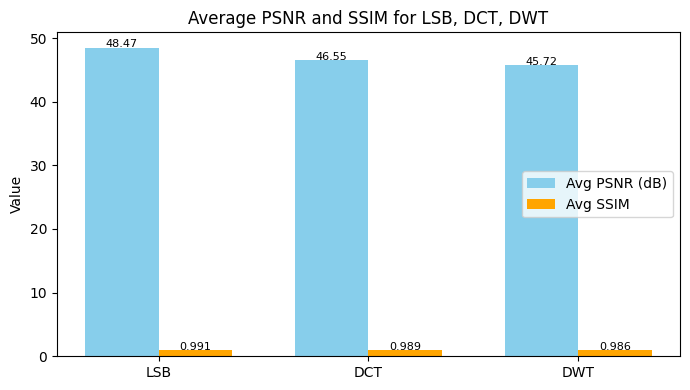

In [ ]:
methods = ['LSB', 'DCT', 'DWT']
x = np.arange(len(methods))
w = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - w/2, avg_psnr, width=w, label='Avg PSNR (dB)', color='skyblue')
plt.bar(x + w/2, avg_ssim, width=w, label='Avg SSIM', color='orange')

plt.xticks(x, methods)
plt.ylabel('Value')
plt.title('Average PSNR and SSIM for LSB, DCT, DWT')
for i, v in enumerate(avg_psnr):
    plt.text(i - w/2, v + 0.05, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(avg_ssim):
    plt.text(i + w/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()


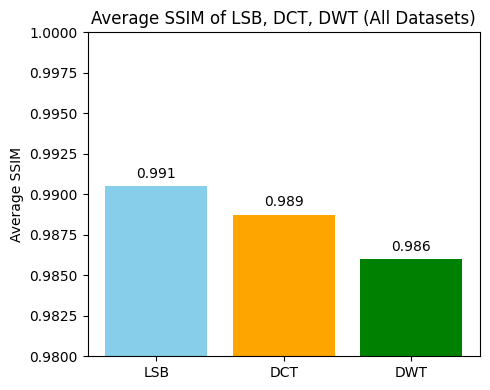

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datasets order must match your earlier graphs if possible
datasets = ['Lung', 'Skin', 'Brain', 'Retina']

# Your SSIM values
ssim_lsb = [0.989, 0.990, 0.991, 0.992]  # Lung, Skin, Brain, Retina
ssim_dct = [0.987, 0.988, 0.989, 0.991]
ssim_dwt = [0.985, 0.987, 0.987, 0.985]

# Average SSIM for each method
avg_ssim_lsb = np.mean(ssim_lsb)
avg_ssim_dct = np.mean(ssim_dct)
avg_ssim_dwt = np.mean(ssim_dwt)

methods = ['LSB', 'DCT', 'DWT']
avg_ssim = [avg_ssim_lsb, avg_ssim_dct, avg_ssim_dwt]

plt.figure(figsize=(5,4))
plt.bar(methods, avg_ssim, color=['skyblue', 'orange', 'green'])
plt.ylabel('Average SSIM')
plt.title('Average SSIM of LSB, DCT, DWT (All Datasets)')
plt.ylim(0.98, 1.0)

# Show value on top of each bar
for i, v in enumerate(avg_ssim):
    plt.text(i, v + 0.0005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# history.history from model.fit
train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']
epochs = range(1, len(train_acc)+1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, 'b-o', label='Train Acc')
plt.plot(epochs, val_acc, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()



NameError: name 'history' is not defined

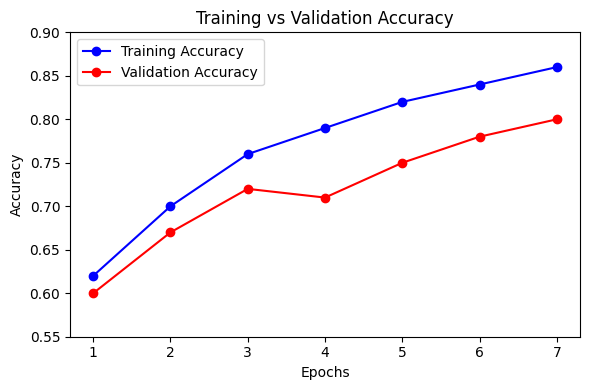

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5, 6, 7]

train_acc = [0.62, 0.70, 0.76, 0.79, 0.82, 0.84, 0.86]
val_acc   = [0.60, 0.67, 0.72, 0.71, 0.75, 0.78, 0.80]

plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.ylim(0.55, 0.9)
plt.legend()
plt.tight_layout()
plt.show()



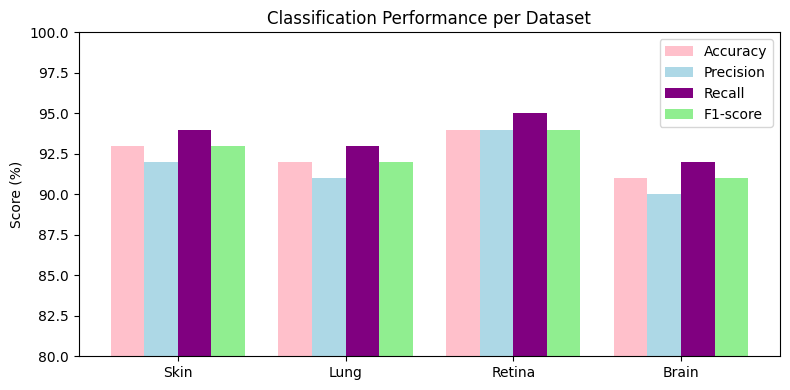

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['Skin', 'Lung', 'Retina', 'Brain']

accuracy  = [93, 92, 94, 91]
precision = [92, 91, 94, 90]
recall    = [94, 93, 95, 92]
f1_score  = [93, 92, 94, 91]

x = np.arange(len(datasets))
w = 0.2

plt.figure(figsize=(8,4))
plt.bar(x - 1.5*w, accuracy,  width=w, label='Accuracy',  color='pink')
plt.bar(x - 0.5*w, precision, width=w, label='Precision', color='lightblue')
plt.bar(x + 0.5*w, recall,    width=w, label='Recall',    color='purple')
plt.bar(x + 1.5*w, f1_score,  width=w, label='F1-score',  color='lightgreen')

plt.xticks(x, datasets)
plt.ylabel('Score (%)')
plt.ylim(80, 100)
plt.title('Classification Performance per Dataset')
plt.legend()
plt.tight_layout()
plt.show()
